<div align="center">

<h1> <b> EFECTOS DE LA PRESIÓN Y DISPERSIÓN EN FASE GASEOSA EN EL CRECIMIENTO DE PELÍCULAS DELGADAS </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>


---

## 1. Introducción y objetivos

Este proyecto estudia qué procesos físicos determinan la morfología de una película delgada de cobre (Cu) depositada sobre vidrio por evaporación térmica en una cámara de vacío. Los mecanismos físicos se incorporan uno a uno en cuadernos independientes, de modo que el efecto de cada uno sobre la morfología pueda distinguirse.

Los cuadernos anteriores supusieron un transporte balístico: cada átomo viaja en línea recta desde la fuente hasta el sustrato. Esa aproximación es razonable en alto vacío, pero los reactores reales operan a presión finita, con moléculas de gas residual (nitrógeno, oxígeno, vapor de agua) contra las que los átomos evaporados pueden colisionar antes de llegar a la película. El cuaderno 5 incorporó el sombreado geométrico mediante un trazador de rayos con condiciones de frontera periódicas. Este sexto cuaderno añade la dispersión en fase gaseosa, gobernada por el camino libre medio $\lambda$, y reúne en un mismo simulador la emisión angular, las colisiones con el gas, el sombreado y la relajación térmica. Sin colisiones ($\lambda \to \infty$) el simulador reproduce el trazador del cuaderno 5.

### Objetivos
* Implementar el transporte en fase gaseosa con distancias libres de distribución exponencial y media $\lambda$, acopladas al trazador de rayos del cuaderno 5.
* Validar el simulador frente a límites conocidos: conservación de partículas, deposición aleatoria y estadística de colisiones.
* Medir cómo varían la rugosidad RMS y las firmas morfológicas con el camino libre medio, tomando el transporte balístico como control.

## 2. Marco teórico y modelo físico

### 2.1 Camino libre medio y presión
Según la teoría cinética, el camino libre medio $\lambda$ es la distancia media que recorre una partícula entre dos colisiones con moléculas del gas. Para un gas ideal de moléculas de diámetro efectivo $d$, a temperatura $T_{\text{gas}}$ y presión $P$, se expresa como (Ohring, 2002)

$$\lambda = \frac{k_B T_{\text{gas}}}{\sqrt{2}\,\pi d^2 P},$$

con $k_B$ la constante de Boltzmann. Este cuaderno no calcula $\lambda$ con esa expresión y lo trata como un parámetro libre. A $T_{\text{gas}}$ y $d$ fijos, $\lambda \propto 1/P$, de modo que un camino libre menor representa una presión mayor. Como en el cuaderno 4, las longitudes se miden en celdas y una capa equivale a una celda, por lo que lo único con significado físico es el cociente $\lambda/L$, donde $L$ es la distancia fuente-película.

### 2.2 Distancia libre y colisiones
En un gas homogéneo, la probabilidad de que una partícula recorra una distancia $s$ sin colisionar es $e^{-s/\lambda}$, de modo que la distancia libre tiene densidad

$$p(s) = \frac{1}{\lambda}\, e^{-s/\lambda}.$$

Se muestrea por transformada inversa, $s = -\lambda \ln(1-\xi)$ con $\xi$ uniforme en $[0,1)$ (Kalos & Whitlock, 2008). Como el gas no tiene memoria, basta sortear una distancia nueva después de cada colisión. Para una trayectoria recta de longitud $\ell$, el número medio de colisiones es $\ell/\lambda$.

La distancia $s$ es longitud de trayectoria y no altura descendida. Si la dirección forma los ángulos $\theta_x$ y $\theta_y$ con la vertical, cada descenso $\Delta z$ recorre

$$\Delta s = \Delta z \sqrt{1 + \tan^2\theta_x + \tan^2\theta_y}.$$

En cada colisión la dirección se perturba con un ruido gaussiano sobre los ángulos de inclinación:

$$\theta_x \leftarrow \theta_x + \mathcal{N}(0, \sigma_{\text{scat}}^2), \qquad \theta_y \leftarrow \theta_y + \mathcal{N}(0, \sigma_{\text{scat}}^2).$$

Es un modelo fenomenológico: la colisión solo cambia la dirección, sin pérdida de energía ni retrodispersión hacia la fuente. En el movimiento solo interviene $\tan\theta$, que tiene periodo $180^\circ$, así que los ángulos quedan definidos módulo $180^\circ$ y el átomo siempre desciende: una desviación acumulada de más de $90^\circ$ equivale a la trayectoria de ángulo $\theta - 180^\circ$. Tras $n$ colisiones la dispersión angular crece como $\sqrt{\sigma_\theta^2 + n\,\sigma_{\text{scat}}^2}$ mientras sea pequeña frente a $90^\circ$. Con muchas colisiones, $\theta_x$ y $\theta_y$ tienden a distribuirse de manera uniforme módulo $180^\circ$ y el flujo se vuelve difuso.

### 2.3 Trazador de rayos con dispersión
El trazador extiende el del cuaderno 5. Cada partícula tiene un punto de mira $(x_0, y_0)$ en el plano $z=0$, elegido con probabilidad uniforme, y ángulos iniciales $\theta_x, \theta_y \sim \mathcal{N}(0, \sigma_\theta)$. Se lanza desde un techo $z_0 = h_{\max} + L$, situado a una distancia $L$ (`SOURCE_DISTANCE`) por encima de la altura máxima $h_{\max}$ de la película, de modo que la geometría del vuelo no depende del espesor. La posición de lanzamiento es

$$x = x_0 + z_0 \tan\theta_x, \qquad y = y_0 + z_0 \tan\theta_y,$$

de manera que, sin colisiones, la recta pasa por el punto de mira en $z=0$.

La partícula desciende por pasos. Cada paso avanza

$$\Delta z_{\text{ef}} = \min\left(\Delta z,\ \frac{1}{\max(|\tan\theta_x|,\, |\tan\theta_y|)}\right),$$

con $\Delta z$ = `PASO_Z`, y se acorta si la siguiente colisión con el gas o el plano $z=0$ quedan antes de completarlo. Con $|\tan\theta| \le 2$ el paso es $\Delta z = 0.5$ y el trazador coincide con el del cuaderno 5. Con pendientes mayores el paso se reduce para que el rayo no avance más de una celda en horizontal y no omita columnas. Las posiciones se toman módulo el tamaño de la malla (condiciones de frontera periódicas), y la partícula colisiona con la superficie en el primer paso en que

$$z \le h\left(x_{\text{pbc}},\, y_{\text{pbc}}\right),$$

donde $h$ es la altura de la celda más próxima. La celda de colisión es donde se incorpora la partícula, antes de la relajación térmica.

### 2.4 Relajación superficial
Tras la colisión, la partícula se relaja con la regla del cuaderno 5: hasta `MAX_DIFFUSION_STEPS` saltos a vecinos de von Neumann estrictamente más bajos, cada uno con probabilidad $P(T)=\min(1, T/T_1)$, donde $T_1 = 500$ K es una temperatura de escala sin calibrar. Por último, $h(i^*, j^*) \leftarrow h(i^*, j^*) + 1$ en la celda final.

### 2.5 Alcance del formalismo
La superficie es una función de altura sin voladizos ni huecos (aproximación SOS): una partícula que choca con la pared lateral de una columna se incorpora en su parte superior, de modo que el modelo no representa el ensanchamiento de las columnas ni la porosidad. El gas se supone homogéneo, con un único camino libre medio, y las colisiones no restan energía a los átomos ni los devuelven hacia la fuente. Las condiciones periódicas representan una sección de un sustrato extenso con flujo uniforme. Sobre una superficie plana, un desplazamiento lateral independiente no altera la distribución uniforme de los puntos de impacto, de modo que la morfología solo cambia con $\lambda$ a través del relieve (sombreado) y no por los bordes de la malla. El trazador muestrea la altura de la superficie en pasos discretos, lo que introduce un error de discretización que se cuantifica en el experimento III (sección 7).

### 2.6 Referencias analíticas y límites de validación
Sea $M = N_x N_y$ el número de celdas y $N$ el número de eventos. Cada evento añade una capa, de modo que $\sum h = N$ y $\overline{h}_{\text{teo}} = N/M$, relación exacta que expresa la conservación del número de partículas. Los demás límites son los siguientes.

* Sin colisiones, sin dispersión angular y sin difusión ($\lambda \to \infty$, $\sigma_\theta = 0$, $T = 0$), todos los rayos son verticales y el modelo se reduce a la deposición aleatoria (RD). Las alturas siguen una distribución de Poisson de media $\overline{h}$, la rugosidad vale $W_{\text{RD}} = \sqrt{\overline{h}}$ y una realización fluctúa alrededor de ese valor con desviación típica $\sigma_W \approx W_{\text{RD}}/\sqrt{2M}$ (cuaderno 1; Barabási & Stanley, 1995, cap. 4).
* Sin colisiones ($\lambda \to \infty$), el simulador reproduce el trazador del cuaderno 5. Esta simulación balística sirve de control para separar el efecto del gas.
* Un átomo que cae verticalmente sobre una superficie plana recorre exactamente $L$, y su número de colisiones es de Poisson con media $L/\lambda$. Esto valida el muestreo de la distancia libre. Sobre una superficie rugosa y con trayectorias oblicuas, el número medio de colisiones es mayor que $L/\lambda$, porque el recorrido parte de $h_{\max} + L$ y es más largo que la vertical.

Con gas y difusión no se usa una predicción analítica de $W$. La validación se apoya en la conservación de partículas, en los límites anteriores y en la comparación con el control balístico.

## 3. Librerías y configuración

El cálculo numérico usa NumPy (Harris et al., 2020) y las tablas de resultados se organizan con pandas (McKinney, 2010). Los ciclos de trazado de rayos, difusión y cálculo de métricas se compilan con Numba (Lam et al., 2015) cuando la librería está instalada; si no lo está, las mismas funciones se ejecutan como Python puro, con más lentitud pero con las mismas propiedades estadísticas. SciPy (Virtanen et al., 2020) aporta la distribución de Poisson de referencia y Matplotlib (Hunter, 2007) se encarga de la visualización.

Numba mantiene un generador de números pseudoaleatorios propio, con un estado independiente del de NumPy: sembrar uno no modifica al otro (Numba, s. f.). Por ello cada simulación fija su semilla dentro de la función compilada (sección 5). Las semillas de las distintas simulaciones se derivan de una única semilla con `SeedSequence` de NumPy, de modo que cada una es independiente y reproducible por separado. Las secuencias de Numba y de NumPy no tienen por qué coincidir para una misma semilla, de manera que una realización concreta solo es reproducible dentro de un mismo modo de ejecución.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import poisson

# Numba es una dependencia opcional de aceleración. Si no está instalada, las
# funciones numéricas se ejecutan sin compilar: el resultado es estadísticamente
# equivalente, aunque más lento.
try:
    from numba import njit
    NUMBA_DISPONIBLE = True
except ImportError:
    NUMBA_DISPONIBLE = False

    def njit(*args, **kwargs):
        """Sustituto de ``numba.njit`` que deja la función sin compilar.

        Admite tanto la forma ``@njit`` como la forma ``@njit(...)``.
        """
        if len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def decorador(funcion):
            return funcion

        return decorador

if not NUMBA_DISPONIBLE:
    print("Numba no está disponible: la simulación se ejecutará en Python puro (más lenta).")

# Mostrar todas las columnas de las tablas de resultados
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

# Estilo de las figuras. La resolución de guardado (300 dpi) es la adecuada
# para insertarlas en un informe.
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120,
    'savefig.dpi': 300
})

## 4. Parámetros del sistema

Las dimensiones de la malla y las distancias se dan en celdas, el número de eventos en partículas depositadas, las temperaturas en kelvin, los ángulos en grados y las alturas en capas. Con 50 000 eventos sobre 200 × 200 celdas el espesor medio es de 1.25 capas, la condición base del cuaderno 5, de modo que los resultados sin gas son comparables con los de ese cuaderno. Con $L = 40$, el camino libre base $\lambda = 15$ corresponde a $\lambda/L = 0.375$. El barrido de $\lambda$ va desde presiones altas ($\lambda = 5$) hasta el vacío ideal ($\lambda \to \infty$).

In [2]:
# Dimensiones del sustrato (número de celdas en cada dirección)
NX = 200
NY = 200

# Condición base, heredada de los cuadernos 4 y 5
N_EVENTOS = 50_000          # partículas por simulación (espesor medio N_EVENTOS / (NX * NY) = 1.25 capas)
TEMPERATURE = 400           # temperatura del sustrato (K)
T_ESCALA = 500              # temperatura de escala de P(T) = min(1, T / T_ESCALA), en kelvin
MAX_DIFFUSION_STEPS = 5     # número máximo de saltos por partícula
GUARDAR_CADA = 500          # intervalo de muestreo de la evolución temporal, en eventos
SIGMA_ANGLE_INIT = 15       # dispersión angular inicial de la emisión sigma_theta, en grados
PASO_Z = 0.5                # paso vertical del trazador de rayos, en capas
SOURCE_DISTANCE = 40        # distancia vertical L entre el techo del reactor y la altura máxima de la película, en celdas

# Dispersión en fase gaseosa
SIGMA_SCATTERING = 20       # desviación angular gaussiana por colisión, en grados
MEAN_FREE_PATH_BASE = 15.0  # camino libre medio lambda de la condición base, en celdas

# Experimento I: barrido del camino libre medio (en celdas). El último valor debe ser
# np.inf: es el control balístico (sin colisiones), al que se refieren las comparaciones.
CAMINOS_LIBRES_PRUEBA = [5.0, 10.0, 15.0, 30.0, 60.0, 200.0, np.inf]

# Experimento II: barrido del espesor con gas (lambda = MFP_ESTUDIO_FIJO) y sin él (lambda = infinito)
VOLUMEN_EVENTOS = [10_000, 25_000, 50_000, 75_000]
MFP_ESTUDIO_FIJO = 15.0

# Experimento III: sensibilidad al paso vertical del trazador (los valores de lambda
# deben pertenecer a CAMINOS_LIBRES_PRUEBA)
MFP_SENSIBILIDAD = [5.0, 15.0]
PASO_Z_FINO = 0.1

# Réplicas independientes por cada valor de los barridos
REPLICAS_ESTADISTICAS = 3

# Caminos libres cuyas superficies se comparan visualmente
MFP_COMPARATIVOS = [5.0, 15.0, 40.0, 200.0]

# Validación de la estadística de colisiones: vuelos verticales sobre una superficie plana
MFP_VALIDACION_VUELO = [5.0, 15.0, 60.0]
N_VUELOS = 20_000

# Tiempo mínimo, en capas depositadas, desde el que se estima el exponente de
# crecimiento efectivo. Se excluye el transitorio inicial de muy baja cobertura.
T_MIN_AJUSTE = 0.25

# Semilla única de la que se derivan las semillas de todas las simulaciones (ver sección 3)
SEMILLA = 42

if not np.isinf(CAMINOS_LIBRES_PRUEBA[-1]):
    raise ValueError("El último valor de CAMINOS_LIBRES_PRUEBA debe ser np.inf (control balístico).")
if not set(MFP_SENSIBILIDAD) <= set(CAMINOS_LIBRES_PRUEBA):
    raise ValueError("MFP_SENSIBILIDAD debe ser un subconjunto de CAMINOS_LIBRES_PRUEBA.")

## 5. Funciones del modelo

La función `calcular_metricas_pbc` obtiene $\overline{h}$ y $W$ con dos recorridos de la malla: primero la media y después las desviaciones respecto a ella. Este esquema evita la cancelación numérica que aparece al restar $\langle h^2\rangle - \langle h\rangle^2$ cuando la media es grande frente a la dispersión. La función `resumir_superficie` calcula con NumPy, sobre una superficie terminada, las métricas que se tabulan.

In [3]:
@njit
def calcular_metricas_pbc(superficie, nx, ny):
    """Calcula el espesor medio y la rugosidad RMS de una superficie.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Altura de cada celda, en capas.
    nx, ny : int
        Número de celdas en cada dirección.

    Devuelve
    --------
    espesor : float
        Altura media, en capas.
    rugosidad : float
        Desviación estándar poblacional de las alturas (divisor nx * ny), en capas.
    """
    # Se calcula primero la media y después las desviaciones respecto a ella
    # (dos pasadas). Restar <h^2> - <h>^2 en una sola pasada perdería precisión
    # cuando la media es grande frente a la dispersión.
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)

    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diferencia = superficie[i, j] - espesor
            suma_varianza += diferencia * diferencia
    rugosidad = np.sqrt(suma_varianza / (nx * ny))

    return espesor, rugosidad


def resumir_superficie(superficie):
    """Resume una superficie terminada.

    Devuelve un diccionario con el espesor medio y la rugosidad RMS (en capas), las
    alturas máxima y mínima y el porcentaje de celdas sin cubrir (altura cero).
    """
    return {
        "espesor": superficie.mean(),
        "rugosidad": superficie.std(),
        "maximo": superficie.max(),
        "minimo": superficie.min(),
        "vacias": 100 * np.mean(superficie == 0),
    }

La función `trazador_rayos_dispersion` implementa la sección 2.3. Sortea los ángulos iniciales, lanza la partícula desde el techo y la hace descender hasta que la superficie la intercepta. La distancia hasta la siguiente colisión se descuenta con la longitud de trayectoria de cada paso, de modo que un rayo oblicuo colisiona con más frecuencia por unidad de altura que uno vertical. El techo de vuelo se calcula a partir de $h_{\max}$, que el ciclo principal mantiene de forma incremental porque las alturas solo crecen; así se evita recorrer toda la malla en cada evento.

In [4]:
@njit
def trazador_rayos_dispersion(x_target, y_target, nx, ny, superficie, sigma_ang, sigma_disp,
                              mfp, max_h_actual, paso_z, distancia_fuente):
    """Determina la celda de colisión de una partícula con sombreado y dispersión en fase gaseosa.

    Los ángulos de emisión theta_x y theta_y se sortean de una distribución normal de
    media cero y desviación sigma_ang (en grados). La partícula se lanza desde un techo
    situado distancia_fuente capas por encima de la altura máxima, con una posición
    lateral tal que, sin colisiones, su recta pasa por el punto de mira (x_target,
    y_target) en z = 0. Desciende por pasos, que no superan paso_z ni permiten un
    avance lateral mayor que una celda, y se acortan para terminar en cada colisión con
    el gas y en el plano z = 0. Las distancias libres siguen una distribución
    exponencial de media mfp; en cada colisión se suma a theta_x y a theta_y un ruido
    normal de desviación sigma_disp. La partícula queda en el primer paso en que su
    altura z no supera la de la celda que sobrevuela. Las posiciones laterales son
    periódicas.

    Parámetros
    ----------
    x_target, y_target : int
        Punto de mira en el plano z = 0.
    nx, ny : int
        Número de celdas en cada dirección.
    superficie : ndarray de enteros, forma (nx, ny)
        Alturas actuales, en capas. La función no las modifica.
    sigma_ang : float
        Desviación estándar de los ángulos de emisión, en grados.
    sigma_disp : float
        Desviación estándar de la desviación angular por colisión, en grados.
    mfp : float
        Camino libre medio, en celdas. Con np.inf no hay colisiones.
    max_h_actual : int
        Altura máxima actual de la superficie, en capas.
    paso_z : float
        Paso vertical máximo del trazado, en capas.
    distancia_fuente : float
        Distancia entre el techo y la altura máxima de la película, en capas.

    Devuelve
    --------
    cx, cy : int
        Índices de la celda de colisión.
    n_col : int
        Número de colisiones con el gas sufridas durante el vuelo.
    """
    theta_x = np.random.normal(0.0, sigma_ang)
    theta_y = np.random.normal(0.0, sigma_ang)

    # Techo de vuelo, medido desde la parte más alta de la película: así la geometría
    # del vuelo no depende del espesor acumulado.
    z = float(max_h_actual) + distancia_fuente

    # Posición de lanzamiento: la recta inicial pasa por el punto de mira en z = 0.
    x = x_target + z * np.tan(theta_x * np.pi / 180.0)
    y = y_target + z * np.tan(theta_y * np.pi / 180.0)

    # Distancia de trayectoria hasta la primera colisión. Como el gas no tiene memoria,
    # basta volver a sortear la distancia después de cada colisión (transformada
    # inversa de la exponencial; 1 - random() está en (0, 1], de modo que el logaritmo
    # es finito).
    if np.isinf(mfp):
        s_libre = np.inf
    else:
        s_libre = mfp * (-np.log(1.0 - np.random.random()))

    n_col = 0
    cx = x_target
    cy = y_target

    while True:
        # Pendientes laterales por capa de descenso con la dirección actual.
        tan_x = np.tan(theta_x * np.pi / 180.0)
        tan_y = np.tan(theta_y * np.pi / 180.0)

        # Con pendientes grandes un paso de paso_z avanzaría varias celdas en horizontal
        # y podría omitir columnas: se limita el avance lateral a una celda por paso.
        # Con |tan| <= 1 / paso_z el paso es paso_z.
        pendiente = max(abs(tan_x), abs(tan_y))
        dz = paso_z
        if pendiente * dz > 1.0:
            dz = 1.0 / pendiente

        # Longitud de trayectoria recorrida en el paso. La distancia libre se mide sobre
        # la trayectoria, no sobre la altura descendida.
        ds = dz * np.sqrt(1.0 + tan_x * tan_x + tan_y * tan_y)

        # Si la colisión ocurre dentro del paso, este termina en el punto de colisión.
        hay_colision = False
        if ds >= s_libre:
            dz = dz * s_libre / ds
            ds = s_libre
            hay_colision = True

        # El descenso termina en z = 0: el sustrato siempre detiene a la partícula.
        if dz >= z:
            dz = z
            hay_colision = False

        z -= dz
        x -= dz * tan_x
        y -= dz * tan_y
        s_libre -= ds

        # Condiciones de frontera periódicas. El resto es no negativo en Python y en
        # Numba; el ajuste solo actúa como salvaguarda.
        idx_x = int(np.round(x)) % nx
        idx_y = int(np.round(y)) % ny
        if idx_x < 0:
            idx_x += nx
        if idx_y < 0:
            idx_y += ny

        # Criterio de interceptación (sombreado)
        if z <= superficie[idx_x, idx_y]:
            cx = idx_x
            cy = idx_y
            break

        # Colisión con el gas: se desvía la dirección y se sortea la siguiente distancia libre.
        if hay_colision:
            theta_x += np.random.normal(0.0, sigma_disp)
            theta_y += np.random.normal(0.0, sigma_disp)
            n_col += 1
            s_libre = mfp * (-np.log(1.0 - np.random.random()))

    return cx, cy, n_col

La función `difundir_particula_pbc` aplica la relajación por descenso con fronteras periódicas, y recorre la vecindad dos veces, primero para contar los vecinos más bajos y luego para localizar el elegido, en lugar de construir un arreglo de candidatos en cada salto. La función `ejecutar_simulacion_dispersion_historial` implementa el ciclo Monte Carlo y registra las métricas cada `guardar_cada` eventos, y `ejecutar_simulacion_dispersion` la invoca sin conservar el historial. El ciclo es estrictamente secuencial: cada rayo se traza sobre el relieve que dejaron los anteriores y todos modifican la misma matriz de alturas, por lo que una simulación no se paraleliza. Las réplicas son independientes entre sí y se ejecutan en serie. Por último, `contar_colisiones_vuelo_libre` reproduce el vuelo vertical sobre una superficie plana que se usa para validar el muestreo de la distancia libre.

In [5]:
@njit
def difundir_particula_pbc(superficie, x, y, nx, ny, temp, t_escala, max_pasos):
    """Aplica la difusión de corto alcance por descenso con fronteras periódicas.

    En cada paso, la partícula salta con probabilidad P = min(1, temp / t_escala)
    a uno de sus vecinos de von Neumann estrictamente más bajos, elegido con igual
    probabilidad. Se detiene si no hay vecinos más bajos, si el salto falla o si
    alcanza max_pasos saltos.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Alturas actuales, en capas. La función no las modifica.
    x, y : int
        Celda de colisión.
    nx, ny : int
        Número de celdas en cada dirección.
    temp : float
        Temperatura del sustrato, en kelvin.
    t_escala : float
        Temperatura de escala de la probabilidad de salto, en kelvin.
    max_pasos : int
        Número máximo de saltos.

    Devuelve
    --------
    curr_x, curr_y : int
        Índices de la celda que recibe la partícula.
    """
    curr_x = x
    curr_y = y

    # Desplazamientos de von Neumann: izquierda, derecha, abajo, arriba
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)

    # Probabilidad de salto según la temperatura
    prob_difusion = temp / t_escala
    if prob_difusion > 1.0:
        prob_difusion = 1.0

    for _ in range(max_pasos):
        curr_h = superficie[curr_x, curr_y]

        # Primer recorrido: número de vecinos estrictamente más bajos, con fronteras periódicas.
        conteo_validos = 0
        for i in range(4):
            nx_c = (curr_x + dx[i]) % nx
            ny_c = (curr_y + dy[i]) % ny
            if nx_c < 0:
                nx_c += nx
            if ny_c < 0:
                ny_c += ny
            if superficie[nx_c, ny_c] < curr_h:
                conteo_validos += 1

        # Sin microvalles en la vecindad, la partícula se deposita.
        if conteo_validos == 0:
            break

        # Intento de salto. Un segundo recorrido localiza al vecino elegido sin
        # crear arreglos temporales en cada paso.
        if np.random.random() < prob_difusion:
            idx = np.random.randint(0, conteo_validos)
            next_x = curr_x
            next_y = curr_y
            contador = 0
            for i in range(4):
                nx_c = (curr_x + dx[i]) % nx
                ny_c = (curr_y + dy[i]) % ny
                if nx_c < 0:
                    nx_c += nx
                if ny_c < 0:
                    ny_c += ny
                if superficie[nx_c, ny_c] < curr_h:
                    if contador == idx:
                        next_x = nx_c
                        next_y = ny_c
                        break
                    contador += 1
            curr_x = next_x
            curr_y = next_y
        else:
            break

    return curr_x, curr_y


@njit
def ejecutar_simulacion_dispersion_historial(nx, ny, n_eventos, temp, t_escala, max_pasos,
                                             sigma_ang, sigma_disp, mfp, paso_z,
                                             distancia_fuente, guardar_cada, semilla):
    """Ejecuta la simulación con sombreado y dispersión en fase gaseosa y registra la evolución temporal.

    Cada evento elige un punto de mira uniforme, traza la partícula hasta su celda de
    colisión (ver ``trazador_rayos_dispersion``), la relaja (ver
    ``difundir_particula_pbc``) y la deposita.

    Parámetros
    ----------
    nx, ny : int
        Número de celdas en cada dirección.
    n_eventos : int
        Número total de eventos, igual al número de partículas depositadas.
    temp, t_escala : float
        Temperatura del sustrato y temperatura de escala de la probabilidad de salto, en kelvin.
    max_pasos : int
        Número máximo de saltos de difusión por partícula.
    sigma_ang : float
        Desviación estándar de los ángulos de emisión, en grados.
    sigma_disp : float
        Desviación angular por colisión con el gas, en grados.
    mfp : float
        Camino libre medio, en celdas (np.inf: sin gas).
    paso_z : float
        Paso vertical máximo del trazador de rayos, en capas.
    distancia_fuente : float
        Distancia entre el techo y la altura máxima de la película, en capas.
    guardar_cada : int
        Intervalo de muestreo, en eventos, de las métricas temporales.
    semilla : int
        Semilla del generador pseudoaleatorio.

    Devuelve
    --------
    superficie : ndarray int32, forma (nx, ny)
        Alturas finales, en capas.
    hist_eventos : ndarray int32
        Número de eventos transcurridos en cada muestreo.
    hist_espesor, hist_rugosidad : ndarray float64
        Espesor medio y rugosidad RMS, en capas, en cada muestreo.
    n_colisiones : int
        Número total de colisiones con el gas de todas las partículas.
    """
    if nx <= 0 or ny <= 0:
        raise ValueError("nx y ny deben ser positivos.")
    if guardar_cada <= 0 or guardar_cada > n_eventos:
        raise ValueError("Se requiere 0 < guardar_cada <= n_eventos.")
    if temp < 0 or t_escala <= 0 or max_pasos < 0:
        raise ValueError("Se requiere temp >= 0, t_escala > 0 y max_pasos >= 0.")
    if sigma_ang < 0 or sigma_disp < 0 or paso_z <= 0 or distancia_fuente <= 0:
        raise ValueError("Se requiere sigma_ang >= 0, sigma_disp >= 0, paso_z > 0 y distancia_fuente > 0.")
    if not mfp > 0:
        raise ValueError("Se requiere mfp > 0 (np.inf representa la ausencia de gas).")

    # En Numba, np.random.seed solo actúa sobre el generador de Numba si se
    # llama dentro de una función compilada; por eso la semilla se fija aquí.
    np.random.seed(semilla)

    superficie = np.zeros((nx, ny), dtype=np.int32)

    # Arreglos de tamaño fijo para el historial: evitan crecer listas dentro
    # del ciclo compilado.
    tamano_hist = n_eventos // guardar_cada
    hist_eventos = np.zeros(tamano_hist, dtype=np.int32)
    hist_espesor = np.zeros(tamano_hist, dtype=np.float64)
    hist_rugosidad = np.zeros(tamano_hist, dtype=np.float64)

    idx_hist = 0
    max_h_actual = 0
    n_colisiones = 0
    for evento in range(1, n_eventos + 1):
        # Punto de mira, equiprobable e independiente de la altura actual.
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)

        # Transporte con sombreado y colisiones, y relajación térmica. Ambos dependen
        # del relieve actual, por lo que los eventos deben procesarse en orden.
        x_col, y_col, n_col = trazador_rayos_dispersion(
            x_i, y_i, nx, ny, superficie, sigma_ang, sigma_disp, mfp, max_h_actual,
            paso_z, distancia_fuente
        )
        n_colisiones += n_col
        x_f, y_f = difundir_particula_pbc(superficie, x_col, y_col, nx, ny, temp, t_escala, max_pasos)
        superficie[x_f, y_f] += 1

        # Las alturas solo crecen: basta comparar con la celda que acaba de recibir la partícula.
        if superficie[x_f, y_f] > max_h_actual:
            max_h_actual = superficie[x_f, y_f]

        # Las métricas se evalúan sobre el estado acumulado de la superficie.
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_pbc(superficie, nx, ny)
            hist_eventos[idx_hist] = evento
            hist_espesor[idx_hist] = esp
            hist_rugosidad[idx_hist] = rug
            idx_hist += 1

    return superficie, hist_eventos, hist_espesor, hist_rugosidad, n_colisiones


@njit
def ejecutar_simulacion_dispersion(nx, ny, n_eventos, temp, t_escala, max_pasos,
                                   sigma_ang, sigma_disp, mfp, paso_z, distancia_fuente, semilla):
    """Ejecuta la simulación y devuelve la superficie final y el número total de colisiones.

    Equivale a ``ejecutar_simulacion_dispersion_historial`` con una única muestra
    temporal al final; los parámetros son los mismos, salvo ``guardar_cada``.
    """
    superficie, _, _, _, n_colisiones = ejecutar_simulacion_dispersion_historial(
        nx, ny, n_eventos, temp, t_escala, max_pasos, sigma_ang, sigma_disp, mfp,
        paso_z, distancia_fuente, n_eventos, semilla
    )
    return superficie, n_colisiones


@njit
def contar_colisiones_vuelo_libre(n_particulas, nx, ny, mfp, paso_z, distancia_fuente, semilla):
    """Número medio de colisiones de átomos que caen verticalmente sobre una superficie plana.

    Sin desviación angular (sigma_ang = sigma_disp = 0) y sin relieve, cada átomo recorre
    exactamente distancia_fuente. El número de colisiones es entonces de Poisson con
    media distancia_fuente / mfp, lo que permite comprobar el muestreo de la distancia libre.
    """
    np.random.seed(semilla)
    superficie = np.zeros((nx, ny), dtype=np.int32)
    total = 0
    for _ in range(n_particulas):
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)
        _, _, n_col = trazador_rayos_dispersion(
            x_i, y_i, nx, ny, superficie, 0.0, 0.0, mfp, 0, paso_z, distancia_fuente
        )
        total += n_col
    return total / n_particulas

## 6. Condición base y validación

Se ejecuta la condición base ($\lambda$ = `MEAN_FREE_PATH_BASE`) con historial temporal, junto con la misma simulación sin gas ($\lambda \to \infty$) como control balístico. En cada simulación se verifica que $\sum h = N$. El exponente de crecimiento efectivo $\beta_{\text{ef}}$ es la pendiente de $\ln W$ frente a $\ln t$ para $t \ge$ `T_MIN_AJUSTE`; en RD vale 1/2.

Después se validan dos límites del modelo. El primero es la deposición aleatoria (sin gas, sin dispersión angular y sin difusión), donde la rugosidad debe coincidir con $W_{\text{RD}} = \sqrt{\overline{h}}$. Esto se juzga con

$$z = \frac{W_{\text{sim}} - W_{\text{RD}}}{\sigma_W/\sqrt{N_{\text{réplicas}}}},$$

y se considera compatible cuando $|z| \le 3$. El segundo es la estadística de colisiones en vuelo libre: el número medio de colisiones de un átomo que cae verticalmente sobre una superficie plana debe ser $L/\lambda$, con una desviación estándar de la media de $\sqrt{(L/\lambda)/N_{\text{vuelos}}}$ (distribución de Poisson), y también se juzga con $|z| \le 3$.

In [6]:
n_celdas = NX * NY
espesor_teo = N_EVENTOS / n_celdas
rugosidad_rd = np.sqrt(espesor_teo)                      # RD: W = sqrt(h)
celdas_vacias_rd = 100 * poisson.pmf(0, espesor_teo)     # % de celdas con h = 0 esperado en RD
x_central = NX // 2                                      # coordenada x de los perfiles unidimensionales

# Semillas independientes y reproducibles derivadas de SEMILLA.
secuencias = np.random.SeedSequence(SEMILLA).spawn(8)
semilla_base = int(secuencias[0].generate_state(1)[0])
semilla_control = int(secuencias[1].generate_state(1)[0])
semillas_rd = secuencias[2].generate_state(REPLICAS_ESTADISTICAS)
semillas_vuelo = secuencias[3].generate_state(len(MFP_VALIDACION_VUELO))
semillas_mfp = [s.generate_state(REPLICAS_ESTADISTICAS) for s in secuencias[4].spawn(len(CAMINOS_LIBRES_PRUEBA))]
semillas_volumenes = [s.generate_state(2 * REPLICAS_ESTADISTICAS) for s in secuencias[5].spawn(len(VOLUMEN_EVENTOS))]
semillas_sensibilidad = [s.generate_state(REPLICAS_ESTADISTICAS) for s in secuencias[6].spawn(len(MFP_SENSIBILIDAD))]
semillas_comparativas = secuencias[7].generate_state(len(MFP_COMPARATIVOS))


def simular_y_resumir(mfp, n_eventos, semilla, temp=TEMPERATURE, sigma_ang=SIGMA_ANGLE_INIT, paso_z=PASO_Z):
    """Simula una réplica, verifica la conservación de partículas y devuelve su resumen y su superficie.

    El resumen incluye el número medio de colisiones con el gas por átomo depositado.
    """
    superficie, n_colisiones = ejecutar_simulacion_dispersion(
        NX, NY, n_eventos, temp, T_ESCALA, MAX_DIFFUSION_STEPS, sigma_ang, SIGMA_SCATTERING,
        mfp, paso_z, SOURCE_DISTANCE, int(semilla)
    )
    # Cada evento añade exactamente una capa, aunque la partícula se relocalice: si la
    # suma no coincide con n_eventos, el resultado es incorrecto aunque no se lance
    # ninguna excepción.
    if superficie.sum() != n_eventos:
        raise RuntimeError(f"La suma de alturas no coincide con n_eventos (lambda = {mfp}, sigma = {sigma_ang}).")
    resumen = resumir_superficie(superficie)
    resumen["colisiones"] = n_colisiones / n_eventos
    return resumen, superficie


def exponente_efectivo(eventos, rugosidad):
    """Pendiente de ln W frente a ln t (t en capas) para t >= T_MIN_AJUSTE."""
    t_capas = eventos / n_celdas
    tramo = t_capas >= T_MIN_AJUSTE
    if np.count_nonzero(tramo) < 3:
        return np.nan      # muy pocas muestras en el tramo: el ajuste no es fiable
    return np.polyfit(np.log(t_capas[tramo]), np.log(rugosidad[tramo]), 1)[0]

In [7]:
print(f"Simulación con gas (lambda = {MEAN_FREE_PATH_BASE} celdas)...")
superficie_base, hist_ev, hist_esp, hist_rug, n_col_base = ejecutar_simulacion_dispersion_historial(
    NX, NY, N_EVENTOS, TEMPERATURE, T_ESCALA, MAX_DIFFUSION_STEPS, SIGMA_ANGLE_INIT,
    SIGMA_SCATTERING, MEAN_FREE_PATH_BASE, PASO_Z, SOURCE_DISTANCE, GUARDAR_CADA, semilla_base
)
print("Simulación de control balístico (lambda = infinito)...")
superficie_control, _, _, hist_rug_control, n_col_control = ejecutar_simulacion_dispersion_historial(
    NX, NY, N_EVENTOS, TEMPERATURE, T_ESCALA, MAX_DIFFUSION_STEPS, SIGMA_ANGLE_INIT,
    SIGMA_SCATTERING, np.inf, PASO_Z, SOURCE_DISTANCE, GUARDAR_CADA, semilla_control
)
print("Simulaciones finalizadas.")

for superficie in (superficie_base, superficie_control):
    if superficie.sum() != N_EVENTOS:
        raise RuntimeError("La suma de alturas no coincide con el número de partículas depositadas.")
resumen_base = resumir_superficie(superficie_base)
resumen_control = resumir_superficie(superficie_control)
beta_base = exponente_efectivo(hist_ev, hist_rug)
beta_control = exponente_efectivo(hist_ev, hist_rug_control)

ANCHO = 66


def fila(etiqueta, valor):
    print(f"{etiqueta:<38}: {valor}")


print("=" * ANCHO)
print("MÉTRICAS DE LA PELÍCULA CON DISPERSIÓN EN FASE GASEOSA".center(ANCHO))
print("=" * ANCHO)
fila("Sustrato (toroidal)", f"{NX} x {NY} celdas")
fila("Partículas depositadas", N_EVENTOS)
fila("Altura máxima alcanzada", f"{resumen_base['maximo']} capas")
fila("Altura mínima alcanzada", f"{resumen_base['minimo']} capas")
print("-" * ANCHO)
fila("Espesor medio simulado", f"{resumen_base['espesor']:.4f} capas")
fila("Espesor medio teórico", f"{espesor_teo:.4f} capas")
print("-" * ANCHO)
fila(f"Rugosidad RMS (lambda = {MEAN_FREE_PATH_BASE:g})", f"{resumen_base['rugosidad']:.4f} capas")
fila("Rugosidad RMS (lambda = infinito)", f"{resumen_control['rugosidad']:.4f} capas")
fila("Rugosidad RMS de referencia (RD)", f"{rugosidad_rd:.4f} capas")
fila("Cociente con gas / balístico", f"{resumen_base['rugosidad'] / resumen_control['rugosidad']:.3f}")
fila(f"Exponente efectivo (lambda = {MEAN_FREE_PATH_BASE:g})", f"{beta_base:.3f} (RD: 0.5)")
fila("Exponente efectivo (lambda = infinito)", f"{beta_control:.3f} (RD: 0.5)")
print("-" * ANCHO)
fila(f"Celdas vacías (lambda = {MEAN_FREE_PATH_BASE:g})", f"{resumen_base['vacias']:.2f} %")
fila("Celdas vacías (lambda = infinito)", f"{resumen_control['vacias']:.2f} %")
fila("Celdas vacías (RD, teoría)", f"{celdas_vacias_rd:.2f} %")
print("-" * ANCHO)
fila("Colisiones por átomo (medidas)", f"{n_col_base / N_EVENTOS:.2f}")
fila("Cociente L / lambda", f"{SOURCE_DISTANCE / MEAN_FREE_PATH_BASE:.2f}")
print("=" * ANCHO)

Simulación con gas (lambda = 15.0 celdas)...
Simulación de control balístico (lambda = infinito)...
Simulaciones finalizadas.
      MÉTRICAS DE LA PELÍCULA CON DISPERSIÓN EN FASE GASEOSA      
Sustrato (toroidal)                   : 200 x 200 celdas
Partículas depositadas                : 50000
Altura máxima alcanzada               : 9 capas
Altura mínima alcanzada               : 0 capas
------------------------------------------------------------------
Espesor medio simulado                : 1.2500 capas
Espesor medio teórico                 : 1.2500 capas
------------------------------------------------------------------
Rugosidad RMS (lambda = 15)           : 0.7253 capas
Rugosidad RMS (lambda = infinito)     : 0.6560 capas
Rugosidad RMS de referencia (RD)      : 1.1180 capas
Cociente con gas / balístico          : 1.106
Exponente efectivo (lambda = 15)      : 0.265 (RD: 0.5)
Exponente efectivo (lambda = infinito): 0.205 (RD: 0.5)
---------------------------------------------------

In [8]:
# Validación 1: sin colisiones, sin dispersión angular y sin difusión (T = 0 K) el modelo
# es la deposición aleatoria, con W = sqrt(h) (cuaderno 1).
sigma_rd = rugosidad_rd / np.sqrt(2 * n_celdas)                # fluctuación de W en una realización
error_estandar = sigma_rd / np.sqrt(REPLICAS_ESTADISTICAS)     # fluctuación de la media de las réplicas
rug_rd_sim = np.mean([
    simular_y_resumir(np.inf, N_EVENTOS, s, temp=0, sigma_ang=0)[0]["rugosidad"] for s in semillas_rd
])
z_rd = (rug_rd_sim - rugosidad_rd) / error_estandar

print("=" * ANCHO)
print("VALIDACIÓN 1: LÍMITE DE DEPOSICIÓN ALEATORIA".center(ANCHO))
print("=" * ANCHO)
fila("Rugosidad RD teórica (sqrt(h))", f"{rugosidad_rd:.4f} capas")
fila("Rugosidad simulada (media de réplicas)", f"{rug_rd_sim:.4f} capas")
fila("Fluctuación esperada de la media", f"{error_estandar:.4f} capas")
fila("Desviación z", f"{z_rd:+.2f}")
print("=" * ANCHO)
if abs(z_rd) <= 3:
    print("Sin mecanismos adicionales, la rugosidad es compatible con RD (|z| <= 3).")
else:
    print("La rugosidad se aparta de RD (|z| > 3): revisar el generador y el algoritmo.")

# Validación 2: estadística de las colisiones. Un vuelo vertical de longitud L sobre una
# superficie plana sufre un número de colisiones de Poisson con media L / lambda.
print()
print("=" * ANCHO)
print("VALIDACIÓN 2: COLISIONES EN VUELO LIBRE".center(ANCHO))
print("=" * ANCHO)
todas_compatibles = True
for mfp_val, semilla in zip(MFP_VALIDACION_VUELO, semillas_vuelo):
    media = contar_colisiones_vuelo_libre(N_VUELOS, NX, NY, mfp_val, PASO_Z, SOURCE_DISTANCE, int(semilla))
    esperado = SOURCE_DISTANCE / mfp_val
    z_vuelo = (media - esperado) / np.sqrt(esperado / N_VUELOS)
    todas_compatibles = todas_compatibles and abs(z_vuelo) <= 3
    fila(f"lambda = {mfp_val:g}: media / L/lambda", f"{media:.4f} / {esperado:.4f}  (z = {z_vuelo:+.2f})")
print("=" * ANCHO)
if todas_compatibles:
    print("El muestreo de la distancia libre es compatible con la exponencial de media lambda (|z| <= 3).")
else:
    print("El número de colisiones se aparta de L/lambda (|z| > 3): revisar el muestreo.")

           VALIDACIÓN 1: LÍMITE DE DEPOSICIÓN ALEATORIA           
Rugosidad RD teórica (sqrt(h))        : 1.1180 capas
Rugosidad simulada (media de réplicas): 1.1211 capas
Fluctuación esperada de la media      : 0.0023 capas
Desviación z                          : +1.34
Sin mecanismos adicionales, la rugosidad es compatible con RD (|z| <= 3).

             VALIDACIÓN 2: COLISIONES EN VUELO LIBRE              
lambda = 5: media / L/lambda          : 7.9843 / 8.0000  (z = -0.78)
lambda = 15: media / L/lambda         : 2.6749 / 2.6667  (z = +0.72)
lambda = 60: media / L/lambda         : 0.6588 / 0.6667  (z = -1.36)
El muestreo de la distancia libre es compatible con la exponencial de media lambda (|z| <= 3).


## 7. Experimentos computacionales

El experimento I barre el camino libre medio a espesor fijo (1.25 capas). Su último valor, $\lambda \to \infty$, es el control balístico. El experimento II barre el espesor con $\lambda$ = `MFP_ESTUDIO_FIJO` y, como control, sin gas, para separar el crecimiento de $W$ con el espesor que ocurre sin colisiones del que estas añaden. El experimento III repite dos valores de $\lambda$ con un paso vertical menor para cuantificar el error de discretización del trazador. Cada valor se simula con `REPLICAS_ESTADISTICAS` réplicas independientes a la temperatura `TEMPERATURE`. Las tablas resumen la media y la desviación estándar muestral (ddof = 1) entre réplicas. Después se generan las superficies individuales que se comparan visualmente en la sección 8.

In [9]:
# Experimento I: barrido del camino libre medio (el último valor es el control balístico)
resultados_mfp = []

for mfp_val, semillas in zip(CAMINOS_LIBRES_PRUEBA, semillas_mfp):
    print(f"Simulando réplicas para lambda = {mfp_val} celdas...")
    resumenes = [simular_y_resumir(mfp_val, N_EVENTOS, s)[0] for s in semillas]
    col = lambda clave: np.array([r[clave] for r in resumenes])

    resultados_mfp.append({
        "Camino libre λ (celdas)": mfp_val,
        "Presión relativa 1/λ (1/celdas)": 1.0 / mfp_val,
        "λ / L": mfp_val / SOURCE_DISTANCE,
        "Colisiones por átomo": col("colisiones").mean(),
        "Espesor medio (capas)": col("espesor").mean(),
        "Rugosidad media (capas)": col("rugosidad").mean(),
        "Desv. rugosidad": col("rugosidad").std(ddof=1),
        "Altura máxima media": col("maximo").mean(),
        "Desv. altura máxima": col("maximo").std(ddof=1),
        "Altura mínima media": col("minimo").mean(),
        "Celdas vacías (%)": col("vacias").mean(),
    })

df_mfp = pd.DataFrame(resultados_mfp)
# La última fila es el control balístico: su rugosidad es la referencia sin gas
df_mfp.insert(7, "W / W(λ→∞)", df_mfp["Rugosidad media (capas)"] / df_mfp["Rugosidad media (capas)"].iloc[-1])
# Tabla resumen del experimento I
df_mfp.round(4)

Simulando réplicas para lambda = 5.0 celdas...
Simulando réplicas para lambda = 10.0 celdas...
Simulando réplicas para lambda = 15.0 celdas...
Simulando réplicas para lambda = 30.0 celdas...
Simulando réplicas para lambda = 60.0 celdas...
Simulando réplicas para lambda = 200.0 celdas...
Simulando réplicas para lambda = inf celdas...


,Camino libre λ (celdas),Presión relativa 1/λ (1/celdas),λ / L,Colisiones por átomo,Espesor medio (capas),Rugosidad media (capas),Desv. rugosidad,W / W(λ→∞),Altura máxima media,Desv. altura máxima,Altura mínima media,Celdas vacías (%)
0,5.0,0.2000,0.125,16.9979,1.25,0.7590,0.0039,1.1573,9.0000,1.0000,0.0,11.4325
1,10.0,0.1000,0.250,7.2002,1.25,0.7364,0.0026,1.1228,8.3333,0.5774,0.0,10.7242
2,15.0,0.0667,0.375,4.3516,1.25,0.7232,0.0090,1.1027,8.0000,1.0000,0.0,10.4242
3,30.0,0.0333,0.750,1.8639,1.25,0.6966,0.0016,1.0622,7.0000,1.7321,0.0,9.7808
4,60.0,0.0167,1.500,0.8535,1.25,0.6717,0.0023,1.0241,6.6667,1.1547,0.0,8.9958
5,200.0,0.0050,5.000,0.2396,1.25,0.6615,0.0021,1.0087,6.0000,0.0000,0.0,8.7250
6,inf,0.0000,inf,0.0000,1.25,0.6558,0.0028,1.0000,6.0000,0.0000,0.0,8.5517


In [10]:
# Experimento II: barrido del espesor con gas (lambda = MFP_ESTUDIO_FIJO) y sin él
resultados_espesores = []

for eventos, semillas in zip(VOLUMEN_EVENTOS, semillas_volumenes):
    print(f"Evaluando la rugosidad para {eventos} eventos...")
    rug = {}
    for k, mfp_val in enumerate((np.inf, MFP_ESTUDIO_FIJO)):
        semillas_mfp_k = semillas[k * REPLICAS_ESTADISTICAS:(k + 1) * REPLICAS_ESTADISTICAS]
        rug[mfp_val] = np.array([
            simular_y_resumir(mfp_val, eventos, s)[0]["rugosidad"] for s in semillas_mfp_k
        ])

    espesor_nominal = eventos / n_celdas
    resultados_espesores.append({
        "Eventos": eventos,
        "Espesor nominal (capas)": espesor_nominal,
        "W balístico": rug[np.inf].mean(),
        "Desv. balístico": rug[np.inf].std(ddof=1),
        "W con gas": rug[MFP_ESTUDIO_FIJO].mean(),
        "Desv. con gas": rug[MFP_ESTUDIO_FIJO].std(ddof=1),
        "Cociente con gas / balístico": rug[MFP_ESTUDIO_FIJO].mean() / rug[np.inf].mean(),
        "W de RD (sqrt(h))": np.sqrt(espesor_nominal),
    })

df_espesores = pd.DataFrame(resultados_espesores)
# Tabla resumen del experimento II
df_espesores.round(3)

Evaluando la rugosidad para 10000 eventos...
Evaluando la rugosidad para 25000 eventos...
Evaluando la rugosidad para 50000 eventos...
Evaluando la rugosidad para 75000 eventos...


,Eventos,Espesor nominal (capas),W balístico,Desv. balístico,W con gas,Desv. con gas,Cociente con gas / balístico,W de RD (sqrt(h))
0,10000,0.250,0.449,0.002,0.458,0.001,1.021,0.500
1,25000,0.625,0.586,0.001,0.620,0.001,1.057,0.791
2,50000,1.250,0.653,0.004,0.721,0.004,1.104,1.118
3,75000,1.875,0.707,0.001,0.794,0.005,1.123,1.369


In [11]:
# Experimento III: sensibilidad de la rugosidad al paso vertical del trazador
resultados_sensibilidad = []

for mfp_val, semillas in zip(MFP_SENSIBILIDAD, semillas_sensibilidad):
    print(f"Simulando lambda = {mfp_val} celdas con paso vertical {PASO_Z_FINO}...")
    rug_fino = np.array([
        simular_y_resumir(mfp_val, N_EVENTOS, s, paso_z=PASO_Z_FINO)[0]["rugosidad"] for s in semillas
    ])
    # Rugosidad con el paso de referencia, tomada del experimento I
    rug_ref = df_mfp.loc[df_mfp["Camino libre λ (celdas)"] == mfp_val, "Rugosidad media (capas)"].iloc[0]
    resultados_sensibilidad.append({
        "Camino libre λ (celdas)": mfp_val,
        f"W (Δz = {PASO_Z})": rug_ref,
        f"W (Δz = {PASO_Z_FINO})": rug_fino.mean(),
        f"Desv. (Δz = {PASO_Z_FINO})": rug_fino.std(ddof=1),
        "Variación relativa (%)": 100 * (rug_fino.mean() / rug_ref - 1),
    })

df_sensibilidad = pd.DataFrame(resultados_sensibilidad)
# Tabla resumen del experimento III
df_sensibilidad.round(4)

Simulando lambda = 5.0 celdas con paso vertical 0.1...
Simulando lambda = 15.0 celdas con paso vertical 0.1...


,Camino libre λ (celdas),W (Δz = 0.5),W (Δz = 0.1),Desv. (Δz = 0.1),Variación relativa (%)
0,5.0,0.7590,0.7755,0.0058,2.1813
1,15.0,0.7232,0.7351,0.0045,1.6537


In [12]:
# Superficies individuales para la comparación morfológica a distintas presiones
superficies_comparativas = {}
for mfp_val, semilla in zip(MFP_COMPARATIVOS, semillas_comparativas):
    _, superficies_comparativas[mfp_val] = simular_y_resumir(mfp_val, N_EVENTOS, semilla)
print("Superficies comparativas generadas para lambda =", MFP_COMPARATIVOS)

Superficies comparativas generadas para lambda = [5.0, 15.0, 40.0, 200.0]


## 8. Visualización de resultados

Las cuatro primeras figuras muestran las firmas morfológicas de la condición base. Las dos siguientes presentan las tendencias de la rugosidad con la presión y con el espesor, con barras de error que indican la desviación estándar entre réplicas. Las tres últimas comparan superficies a distintos caminos libres medios, con escalas comunes. Además de mostrarse en el cuaderno, cada figura se guarda como archivo PNG en el directorio de trabajo.

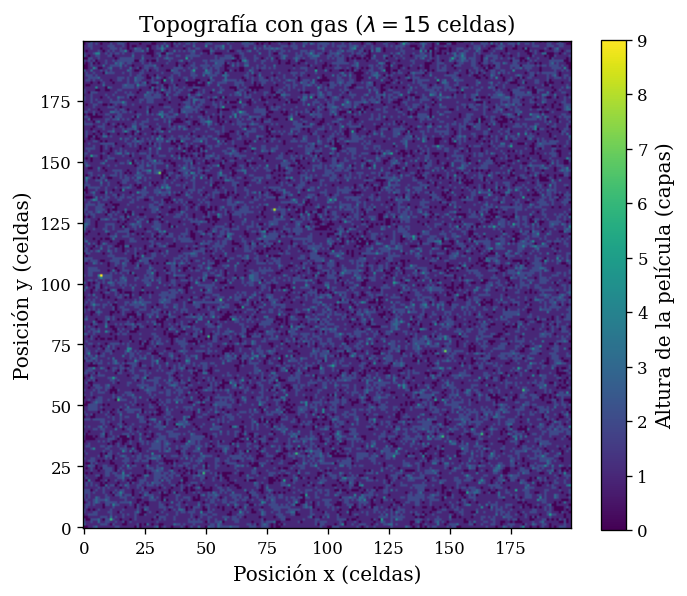

In [13]:
# Topografía de la condición base
fig, ax = plt.subplots(figsize=(6, 5))
# Se transpone la matriz para que el eje horizontal sea x (primer índice de la
# malla) y el vertical sea y (segundo índice); imshow dibuja el primer índice en vertical.
imagen = ax.imshow(superficie_base.T, origin="lower", cmap="viridis")
fig.colorbar(imagen, ax=ax, label="Altura de la película (capas)")
ax.set_xlabel("Posición x (celdas)")
ax.set_ylabel("Posición y (celdas)")
ax.set_title(rf"Topografía con gas ($\lambda = {MEAN_FREE_PATH_BASE:g}$ celdas)")
fig.tight_layout()
fig.savefig("scattering_topografia_2d.png", bbox_inches="tight")
plt.show()

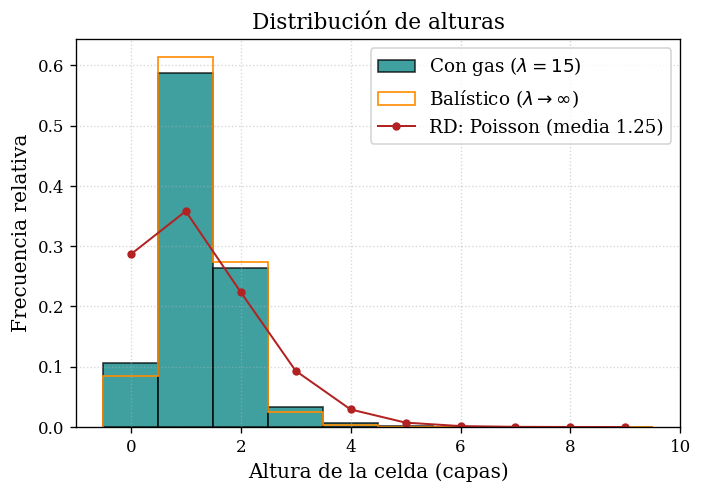

In [14]:
# Distribución de alturas de la condición base frente al control balístico y a la estadística de Poisson (RD)
altura_sup = max(int(resumen_base["maximo"]), int(resumen_control["maximo"]), int(np.ceil(espesor_teo + 5 * rugosidad_rd)))
bordes = np.arange(0, altura_sup + 2) - 0.5          # un intervalo de anchura unidad por altura entera
alturas_enteras = np.arange(0, altura_sup + 1)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
# Con density=True e intervalos de anchura unidad, la altura de cada barra es la
# frecuencia relativa de esa altura.
ax.hist(
    superficie_base.ravel(), bins=bordes, density=True, color="teal",
    edgecolor="black", alpha=0.75, label=rf"Con gas ($\lambda = {MEAN_FREE_PATH_BASE:g}$)",
)
ax.hist(
    superficie_control.ravel(), bins=bordes, density=True, histtype="step", lw=1.6,
    color="darkorange", label=r"Balístico ($\lambda \to \infty$)",
)
ax.plot(
    alturas_enteras, poisson.pmf(alturas_enteras, espesor_teo), "o-", color="firebrick",
    markersize=4, linewidth=1.2, label=f"RD: Poisson (media {espesor_teo:g})",
)
ax.set_xlabel("Altura de la celda (capas)")
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Distribución de alturas")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()
fig.savefig("scattering_histograma.png", bbox_inches="tight")
plt.show()

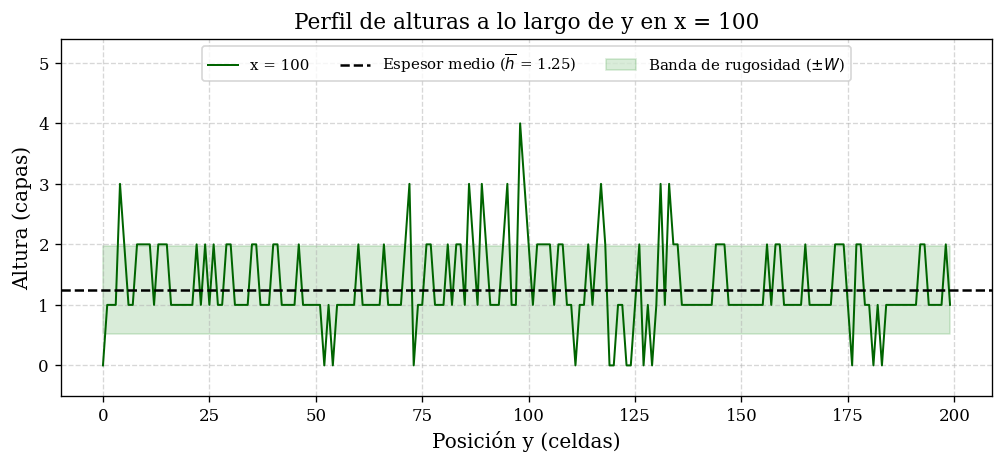

In [15]:
# Perfil unidimensional de la condición base: alturas a lo largo de y en la coordenada x central
perfil = superficie_base[x_central, :]
espesor_base = resumen_base["espesor"]
rugosidad_base = resumen_base["rugosidad"]

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(perfil, color="darkgreen", linewidth=1.2, label=f"x = {x_central}")
ax.axhline(
    espesor_base, color="black", linestyle="--",
    label=rf"Espesor medio ($\overline{{h}}$ = {espesor_base:.2f})",
)
ax.fill_between(
    range(NY), espesor_base - rugosidad_base, espesor_base + rugosidad_base,
    color="green", alpha=0.15, label=r"Banda de rugosidad ($\pm W$)",
)
ax.set_title(f"Perfil de alturas a lo largo de y en x = {x_central}")
ax.set_xlabel("Posición y (celdas)")
ax.set_ylabel("Altura (capas)")
ax.grid(True, linestyle="--", alpha=0.5)
# Margen superior para que la leyenda no tape el perfil.
ax.set_ylim(min(perfil.min(), 0) - 0.5, perfil.max() + 0.35 * (perfil.max() - perfil.min()))
ax.legend(loc="upper center", ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig("scattering_perfil_1d.png", bbox_inches="tight")
plt.show()

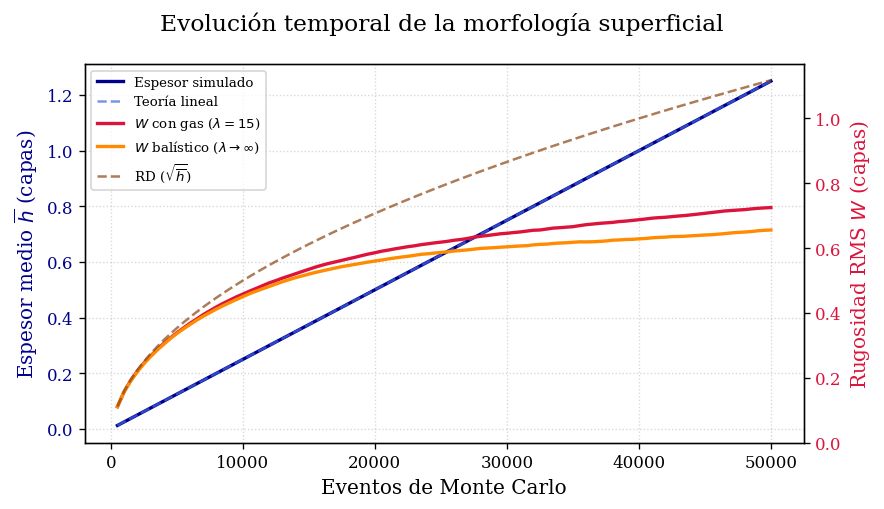

In [16]:
# Evolución temporal con y sin gas, frente a la referencia RD
fig, ax1 = plt.subplots(figsize=(7.5, 4.3))

color_esp = "darkblue"
ax1.set_xlabel("Eventos de Monte Carlo")
ax1.set_ylabel(r"Espesor medio $\overline{h}$ (capas)", color=color_esp)
ax1.plot(hist_ev, hist_esp, color=color_esp, linewidth=2, label="Espesor simulado")
ax1.plot(hist_ev, hist_ev / n_celdas, "--", color="royalblue", alpha=0.7, label="Teoría lineal")
ax1.tick_params(axis="y", labelcolor=color_esp)
ax1.grid(True, linestyle=":", alpha=0.5)

# Segundo eje vertical para la rugosidad, cuya escala numérica es distinta.
ax2 = ax1.twinx()
color_rug = "crimson"
ax2.set_ylabel(r"Rugosidad RMS $W$ (capas)", color=color_rug)
ax2.plot(hist_ev, hist_rug, color=color_rug, linewidth=2, label=rf"$W$ con gas ($\lambda = {MEAN_FREE_PATH_BASE:g}$)")
ax2.plot(hist_ev, hist_rug_control, color="darkorange", linewidth=2, label=r"$W$ balístico ($\lambda \to \infty$)")
ax2.plot(hist_ev, np.sqrt(hist_ev / n_celdas), "--", color="saddlebrown", alpha=0.7, label=r"RD ($\sqrt{\overline{h}}$)")
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=color_rug)

fig.suptitle("Evolución temporal de la morfología superficial")
fig.tight_layout()

# Una sola leyenda con las curvas de ambos ejes
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left", fontsize=8)
fig.savefig("scattering_evolucion_temporal.png", bbox_inches="tight")
plt.show()

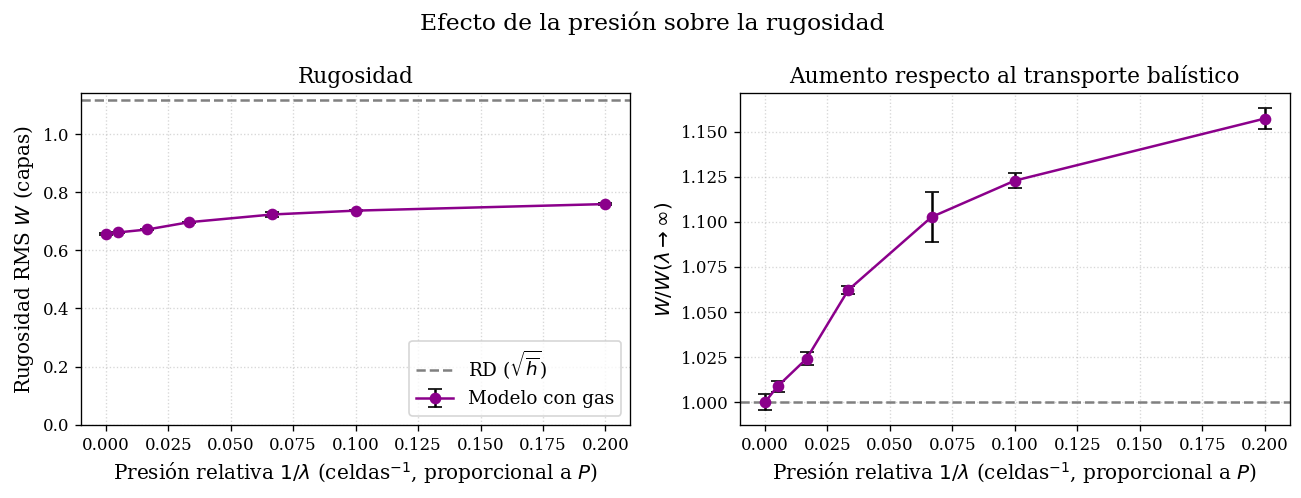

In [17]:
# Rugosidad frente a la presión relativa: valor absoluto y cociente respecto al control balístico
presion_relativa = df_mfp["Presión relativa 1/λ (1/celdas)"]   # el control balístico está en 1/λ = 0
rug_control_media = df_mfp["Rugosidad media (capas)"].iloc[-1]

fig, (ax_w, ax_c) = plt.subplots(1, 2, figsize=(11, 4.2))

ax_w.errorbar(
    presion_relativa, df_mfp["Rugosidad media (capas)"], yerr=df_mfp["Desv. rugosidad"],
    fmt="o-", color="darkmagenta", ecolor="black", capsize=4, lw=1.5, label="Modelo con gas",
)
ax_w.axhline(rugosidad_rd, color="gray", linestyle="--", label=r"RD ($\sqrt{\overline{h}}$)")
ax_w.set_ylim(bottom=0)
ax_w.set_ylabel(r"Rugosidad RMS $W$ (capas)")
ax_w.set_title("Rugosidad")
ax_w.legend(loc="lower right")

ax_c.errorbar(
    presion_relativa, df_mfp["W / W(λ→∞)"], yerr=df_mfp["Desv. rugosidad"] / rug_control_media,
    fmt="o-", color="darkmagenta", ecolor="black", capsize=4, lw=1.5,
)
ax_c.axhline(1.0, color="gray", linestyle="--")
ax_c.set_ylabel(r"$W / W(\lambda \to \infty)$")
ax_c.set_title("Aumento respecto al transporte balístico")

for ax in (ax_w, ax_c):
    ax.set_xlabel(r"Presión relativa $1/\lambda$ (celdas$^{-1}$, proporcional a $P$)")
    ax.grid(True, linestyle=":", alpha=0.5)
fig.suptitle("Efecto de la presión sobre la rugosidad")
fig.tight_layout()
fig.savefig("scattering_tendencia_presion.png", bbox_inches="tight")
plt.show()

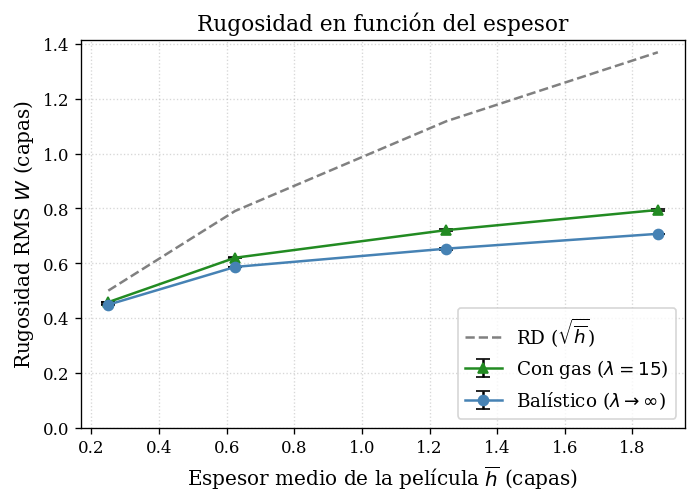

In [18]:
# Rugosidad frente al espesor nominal, con y sin gas
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(
    df_espesores["Espesor nominal (capas)"], df_espesores["W con gas"],
    yerr=df_espesores["Desv. con gas"], fmt="^-", color="forestgreen", ecolor="black",
    capsize=4, lw=1.5, label=rf"Con gas ($\lambda = {MFP_ESTUDIO_FIJO:g}$)",
)
ax.errorbar(
    df_espesores["Espesor nominal (capas)"], df_espesores["W balístico"],
    yerr=df_espesores["Desv. balístico"], fmt="o-", color="steelblue", ecolor="black",
    capsize=4, lw=1.5, label=r"Balístico ($\lambda \to \infty$)",
)
ax.plot(
    df_espesores["Espesor nominal (capas)"], df_espesores["W de RD (sqrt(h))"], "--",
    color="gray", label=r"RD ($\sqrt{\overline{h}}$)",
)
ax.set_xlabel(r"Espesor medio de la película $\overline{h}$ (capas)")
ax.set_ylabel(r"Rugosidad RMS $W$ (capas)")
ax.set_ylim(bottom=0)
ax.set_title("Rugosidad en función del espesor")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="lower right")
fig.savefig("scattering_tendencia_espesor.png", bbox_inches="tight")
plt.show()

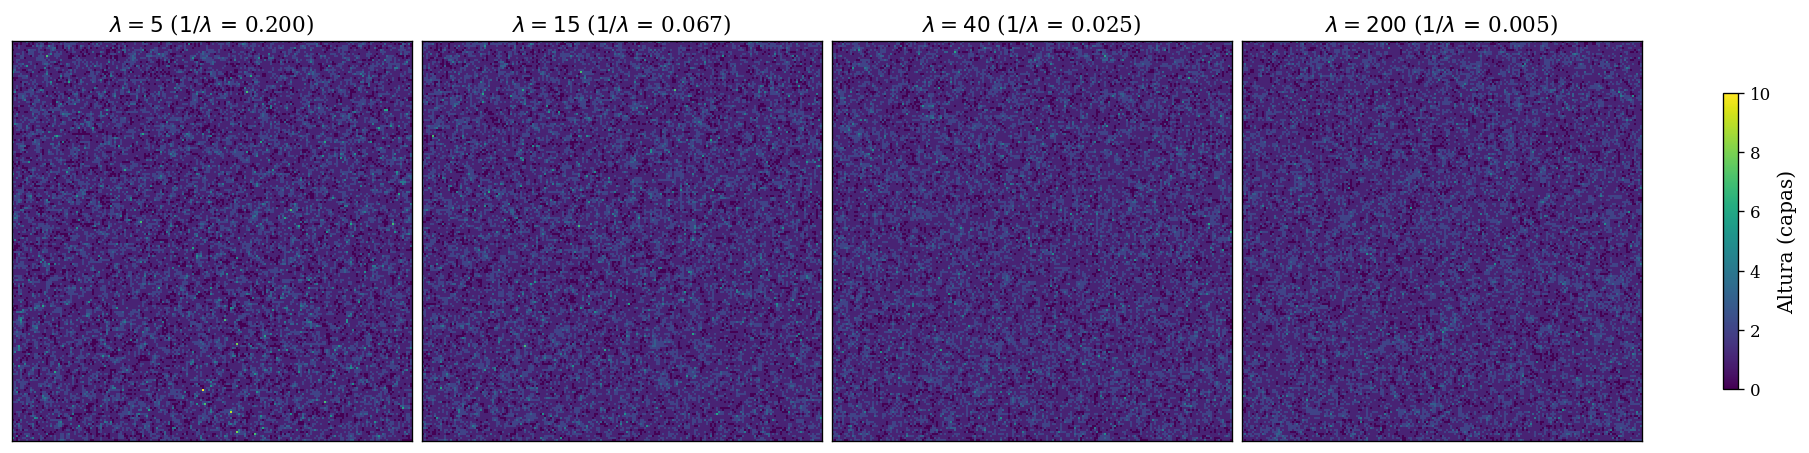

In [19]:
# Mapas topográficos a distintos caminos libres, con una escala de color común
fig, axes = plt.subplots(1, len(MFP_COMPARATIVOS), figsize=(15, 3.8), constrained_layout=True)
vmax_comun = max(int(superficies_comparativas[m].max()) for m in MFP_COMPARATIVOS)

for ax, mfp_val in zip(axes, MFP_COMPARATIVOS):
    # Se transpone la matriz para que el eje horizontal sea x (primer índice de la malla).
    imagen = ax.imshow(
        superficies_comparativas[mfp_val].T, origin="lower", cmap="viridis", vmin=0, vmax=vmax_comun
    )
    ax.set_title(rf"$\lambda = {mfp_val:g}$ ($1/\lambda$ = {1 / mfp_val:.3f})")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(imagen, ax=axes, shrink=0.7, label="Altura (capas)")
fig.savefig("scattering_comparativa_2d.png", bbox_inches="tight")
plt.show()

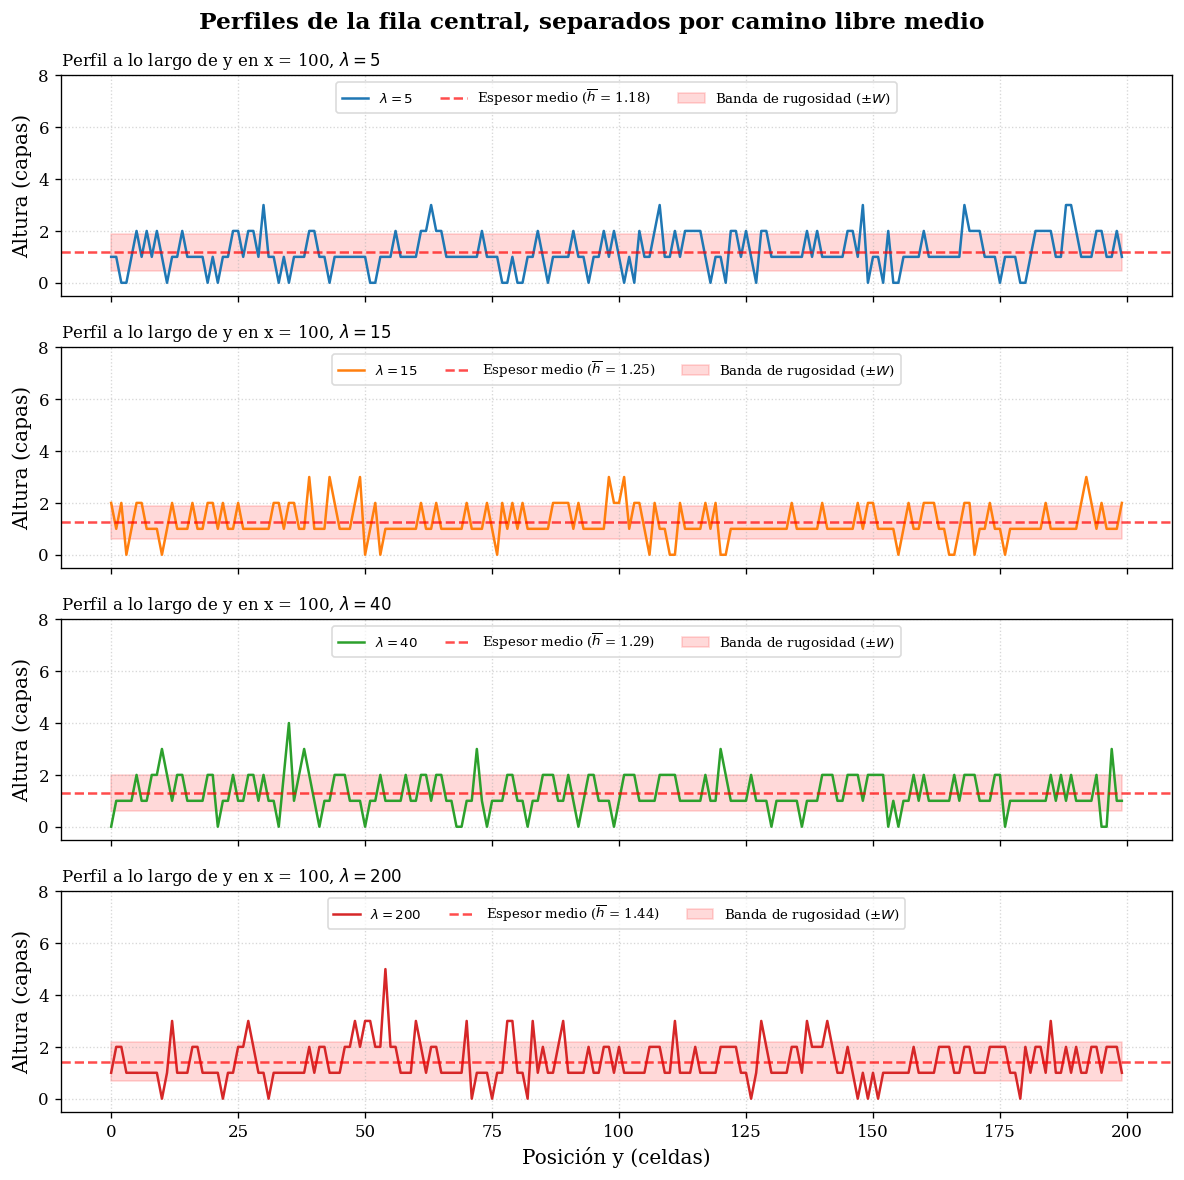

In [20]:
# Perfiles de la fila central, separados por camino libre medio
colores = plt.cm.tab10.colors
fig, axes = plt.subplots(len(MFP_COMPARATIVOS), 1, figsize=(10, 10), sharex=True, sharey=True)

for ax, mfp_val, color in zip(axes, MFP_COMPARATIVOS, colores):
    perfil = superficies_comparativas[mfp_val][x_central, :]
    ax.plot(perfil, lw=1.5, color=color, label=rf"$\lambda = {mfp_val:g}$")
    ax.axhline(
        perfil.mean(), color="red", linestyle="--", alpha=0.7,
        label=rf"Espesor medio ($\overline{{h}}$ = {perfil.mean():.2f})",
    )
    ax.fill_between(
        range(NY), perfil.mean() - perfil.std(), perfil.mean() + perfil.std(),
        color="red", alpha=0.15, label=r"Banda de rugosidad ($\pm W$)",
    )
    ax.set_title(rf"Perfil a lo largo de y en x = {x_central}, $\lambda = {mfp_val:g}$", fontsize=10, loc="left")
    ax.set_ylabel("Altura (capas)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper center", ncol=3, fontsize=8, framealpha=0.7)

# Escala vertical ajustada a los perfiles mostrados, con margen para las leyendas
y_max_perfiles = max(int(superficies_comparativas[m][x_central, :].max()) for m in MFP_COMPARATIVOS)
axes[0].set_ylim(-0.5, 1.6 * y_max_perfiles)
axes[-1].set_xlabel("Posición y (celdas)")
fig.suptitle("Perfiles de la fila central, separados por camino libre medio", fontweight="bold")
fig.tight_layout()
fig.savefig("scattering_comparativa_perfiles_subplots.png", bbox_inches="tight")
plt.show()

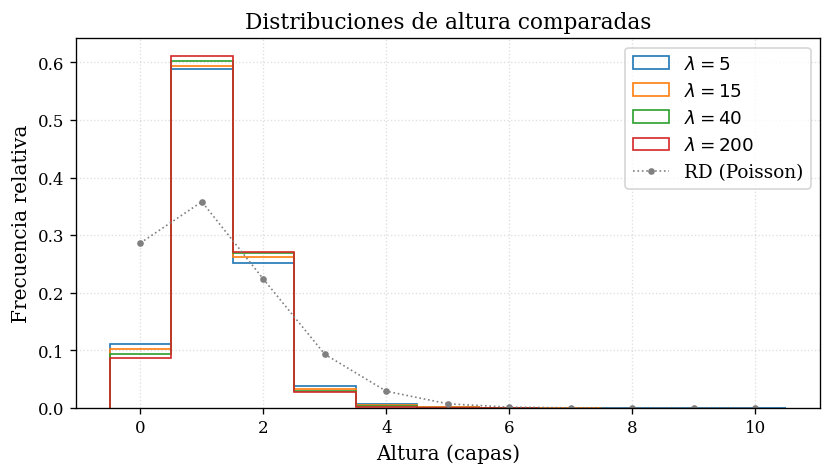

In [21]:
# Distribuciones de alturas a distintos caminos libres medios
fig, ax = plt.subplots(figsize=(8, 4))
for mfp_val, color in zip(MFP_COMPARATIVOS, colores):
    superficie = superficies_comparativas[mfp_val]
    # Un intervalo de anchura unidad por altura entera: con density=True, la altura
    # del escalón es la frecuencia relativa de esa altura.
    ax.hist(
        superficie.ravel(), bins=np.arange(superficie.min(), superficie.max() + 2) - 0.5,
        density=True, histtype="step", lw=1.6, color=color, label=rf"$\lambda = {mfp_val:g}$",
    )
alturas_rd = np.arange(0, max(int(s.max()) for s in superficies_comparativas.values()) + 1)
ax.plot(
    alturas_rd, poisson.pmf(alturas_rd, espesor_teo), "o:", color="gray",
    markersize=3, linewidth=1.0, label="RD (Poisson)",
)
ax.set_xlabel("Altura (capas)")
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Distribuciones de altura comparadas")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()
fig.savefig("scattering_comparativa_histogramas.png", bbox_inches="tight")
plt.show()

## 9. Análisis de resultados

### 9.1 Condición base y validación
La condición base ($\lambda = 15$, $\lambda/L = 0.375$, $T = 400$ K) deposita 1.25 capas de espesor medio, valor exacto por conservación de partículas. Su rugosidad es de unas 0.72 capas, alrededor de un 10 % mayor que la del control balístico (unas 0.66 capas, compatible con la condición base del cuaderno 5) y bastante menor que la de RD ($\sqrt{1.25} = 1.12$). Las celdas sin cubrir pasan de aproximadamente un 8.5 % sin gas a algo más del 10 % con gas, lejos del 28.7 % de RD, de modo que la película sigue siendo casi continua. La altura máxima, de 9 capas en la realización ejecutada, es mayor que la de unas 6 capas del control balístico (experimento I). El exponente efectivo, de unos 0.27 con gas y 0.2 sin él, queda muy por debajo del 0.5 de RD, como en el cuaderno 5. Cada átomo sufre unas 4.4 colisiones, más que las $L/\lambda \approx 2.7$ de un vuelo vertical de longitud $L$, porque su recorrido parte de $h_{\max} + L$ y es oblicuo. La salida de la sección 6 informa las cifras de la realización ejecutada.

Los dos límites de validación se cumplen. Sin gas, sin dispersión angular y sin difusión, la rugosidad coincide con la de RD dentro de la fluctuación esperada, y el número medio de colisiones de un vuelo vertical sobre una superficie plana coincide con $L/\lambda$ para los tres caminos libres ensayados ($|z| \le 3$). Con la conservación de partículas, esto respalda el muestreo de la distancia libre y el límite de deposición aleatoria. Sin gas, además, el simulador coincide con el trazador del cuaderno 5, cuya condición base también da $W \approx 0.65$.

### 9.2 Efecto del camino libre medio
La rugosidad crece de forma monótona con la presión (experimento I y figura de tendencia). Desde $\lambda = 200$, prácticamente balístico, hasta $\lambda = 5$, $W$ pasa de unas 0.66 a unas 0.76 capas, un 16 % más que el control. Las diferencias entre valores no adyacentes superan con holgura la desviación entre réplicas (entre 0.002 y 0.009 capas), mientras que para $\lambda \ge 60$ el efecto es de un 1 a un 2 % y queda cerca de esa incertidumbre. La altura máxima media aumenta de 6 a 9 capas y las celdas vacías, de un 8.6 % sin gas a un 11.4 %. El número de colisiones por átomo va de 0.24 a 17 y supera siempre a $L/\lambda$, por un factor de aproximadamente 1.2 con $\lambda = 200$ y 2.1 con $\lambda = 5$: cuantas más colisiones sufre un átomo, más se inclina su trayectoria y más larga es.

Como referencia, en el cuaderno 5 abrir la emisión elevaba $W$ un 4 % con $\sigma_\theta = 15^\circ$ y entre un 9 y un 10 % con $25^\circ$, respecto a la emisión vertical. Con el gas, la distribución angular de llegada se ensancha mucho más que con esos ángulos de emisión y el aumento llega al 16 %.

### 9.3 Interpretación
Sobre una superficie plana, la dispersión no altera la distribución uniforme de los puntos de impacto, de modo que el efecto observado procede del relieve. Cada colisión ensancha la distribución angular con la que los átomos alcanzan la película. Cuanto más oblicua es la llegada, más flujo interceptan las elevaciones y menos alcanza los valles vecinos (Karunasiri et al., 1989). La difusión a 400 K compensa solo una parte de ese efecto, y por eso la rugosidad aumenta.

El modelo no produce el suavizado por presión que suele invocarse cuando el gas redistribuye el flujo hacia los valles: la rugosidad, las celdas vacías y la altura máxima crecen con la presión. Una redistribución local requeriría colisiones a la altura del relieve, y con $L = 40$ y $h_{\max} \lesssim 9$ el descenso dentro del intervalo del relieve es como máximo un 20 % de la altura total de vuelo, de modo que la mayoría de las colisiones ocurre por encima de él. Como referencia cualitativa, en depósitos por sputtering el aumento de la presión del gas se asocia con estructuras más porosas y abiertas, la zona 1 del modelo de zonas de estructura de Thornton (1977). El modelo SOS y las 1.25 capas simuladas no permiten contrastar la porosidad, por lo que la coincidencia se limita al sentido de la tendencia.

### 9.4 Efecto del espesor
Con gas y sin él, la rugosidad crece con el espesor más despacio que $\sqrt{\overline{h}}$ y no alcanza la de RD (experimento II). El cociente entre la rugosidad con gas ($\lambda = 15$) y sin gas aumenta con el espesor, de unos 1.02 con 0.25 capas a unos 1.12 con 1.875 capas. La dispersión actúa a través del relieve ya formado: una película casi plana no tiene elevaciones que sombreen y el gas apenas la modifica, igual que ocurría con el sombreado en el cuaderno 5. No se exploraron espesores mayores.

### 9.5 Firmas morfológicas
Los mapas topográficos a distintos $\lambda$ se parecen entre sí, con celdas elevadas aisladas sobre un fondo casi continuo, y la diferencia se aprecia sobre todo en las distribuciones de altura. Todas son mucho más estrechas que la de Poisson de RD y se concentran en una capa. Al aumentar la presión disminuye ligeramente la fracción de celdas de una y dos capas y aumentan las de altura cero y las de tres o más capas, de modo que la distribución se ensancha. Los perfiles de la fila central muestran variaciones de una o dos capas entre celdas vecinas, sin columnas anchas ni agrupaciones de mayor escala.

### 9.6 Sensibilidad numérica y alcance
Reducir el paso vertical de 0.5 a 0.1 capas eleva $W$ en torno a un 2 % con $\lambda = 5$ y a un 1.7 % con $\lambda = 15$ (experimento III). Los valores absolutos de $W$ con gas tienen por tanto un error de discretización de unos pocos por ciento, pequeño frente al aumento del 16 % que produce el gas con $\lambda = 5$. Se usa $\Delta z = 0.5$ para mantener la equivalencia con el cuaderno 5.

El resto de las limitaciones ya aparece en la sección 2.5. El modelo SOS no representa porosidad ni columnas anchas. El gas es homogéneo, con un único $\lambda$, y las colisiones no restan energía ni retrodispersan. Las longitudes están en unidades de celda, de modo que solo $\lambda/L$ tiene significado, y una comparación cuantitativa con presiones reales exigiría calibrar esa escala. La temperatura $T_1$ sigue sin calibrar y tres réplicas por punto dan una estimación gruesa de la incertidumbre. Los resultados deben leerse como tendencias cualitativas.

## 10. Conclusiones

* El simulador reúne en un solo modelo la emisión angular, las colisiones con el gas, el sombreado geométrico y la relajación térmica. Conserva el número de partículas, reproduce la deposición aleatoria en su límite y muestrea la distancia libre con la media $\lambda$ esperada. Sin gas coincide con el trazador del cuaderno 5.
* La rugosidad crece de forma monótona con la presión. Entre el transporte balístico y $\lambda = 5$ pasa de unas 0.66 a unas 0.76 capas, y aumentan también las celdas sin cubrir y la altura máxima. El modelo no muestra un suavizado por presión: las colisiones ensanchan la distribución angular de llegada y refuerzan el sombreado, que la difusión a 400 K solo compensa en parte.
* El efecto del gas crece con el espesor, de un 2 % con 0.25 capas a un 12 % con 1.875 capas, porque actúa a través del relieve ya formado. Las cifras absolutas tienen un error de discretización de unos pocos por ciento y dependen de la escala de longitudes y de $T_1$, ambas sin calibrar. Un estudio cuantitativo requeriría calibrarlas y modelar la porosidad, que el esquema SOS no puede representar.

## 11. Referencias

### Fuentes académicas primarias

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.

* Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

* Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

* Kalos, M. H., & Whitlock, P. A. (2008). *Monte Carlo methods* (2.ª ed.). Wiley-VCH. https://doi.org/10.1002/9783527626212

* Karunasiri, R. P. U., Bruinsma, R., & Rudnick, J. (1989). Thin-film growth and the shadow instability. *Physical Review Letters, 62*(7), 788–791. https://doi.org/10.1103/PhysRevLett.62.788

* Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. En *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC (LLVM '15)* (Artículo 7, pp. 1–6). Association for Computing Machinery. https://doi.org/10.1145/2833157.2833162

* McKinney, W. (2010). Data structures for statistical computing in Python. En S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

* Ohring, M. (2002). *Materials science of thin films: Deposition and structure* (2.ª ed.). Academic Press.

* Thornton, J. A. (1977). High rate thick film growth. *Annual Review of Materials Science, 7*, 239–260. https://doi.org/10.1146/annurev.ms.07.080177.001323

* Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

### Recursos complementarios

* Numba. (s. f.). *Supported NumPy features*. Numba documentation. https://numba.pydata.org/numba-doc/latest/reference/numpysupported.html